# Chapter 7: Telling Birds from Airplanes: Learning From Images

A dataset of tiny images

Here, we will use another dataset that is similarly simple and a bit more fun. It’s
called CIFAR-10, and like its sibling CIFAR-100, it has been a computer vision classic for a decade.
 CIFAR-10 consists of 60,000 tiny 32 × 32 color (RGB) images, labeled with an integer corresponding to 1 of 10 classes: airplane (0), automobile (1), bird (2), cat (3),
deer (4), dog (5), frog (6), horse (7), ship (8), and truck (9).

We will use the torchvision
module to automatically download the dataset and load it as a collection of PyTorch
tensors.

# Downloading CIFAR-10

Let’s import torchvision and use the datasets module to download the CIFAR-10
data.

In [1]:
from torchvision import datasets
import os

from src.Chapter_5_TheMechanicsOfLearning import training_loop

data_path = '../data/cifar10/'
os.makedirs(data_path, exist_ok=True)

# Instantiates a dataset for the training data; TorchVision downloads the data if it is not present.
cifar10 = datasets.CIFAR10(data_path, train=True, download=True)

# With train=False, we get a dataset for the validation data, again downloading as necessary
cifar10_val = datasets.CIFAR10(data_path, train=False, download=True)

100%|██████████| 170M/170M [31:24<00:00, 90.5kB/s] 


The first argument we provide to the CIFAR10 function is the local directory where the
data will be downloaded. The second argument specifies whether we’re interested in
the training set or the validation set. Finally, the third argument determines whether
we allow PyTorch to download the data if it is not found in the location specified in
the first argument.

 In each case, the dataset is returned as a subclass of torch
.utils.data.Dataset. We can see that the method-resolution order of our cifar10
instance includes it as a base class:

In [3]:
type(cifar10).__mro__

(torchvision.datasets.cifar.CIFAR10,
 torchvision.datasets.vision.VisionDataset,
 torch.utils.data.dataset.Dataset,
 typing.Generic,
 object)

### The Dataset class

It’s a good time to discover what a subclass of torch.utils.data.Dataset means in
practice... We see what PyTorch’s Dataset is all about. It is an
object that should have two methods implemented: __len__ and __getitem__. The former should return the number of items in the dataset, and the latter should return
the item, consisting of a sample and its corresponding label (an integer index). We
return a sample and label for our image classification example, but getitem could
return any data point (with or without corresponding labels, for instance).

In practice, when a Python object is equipped with the __len__ method, we can pass it
as an argument to the len Python built-in function:

In [2]:
len(cifar10)

50000

Similarly, since the dataset is equipped with the __getitem__ method, we can use the
standard subscript for indexing tuples and lists to access individual items. Here, we get
a PIL (Python Imaging Library, the PIL package) image with our desired output—an
integer with the value 1, corresponding to “automobile”:

In [4]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

img, label = cifar10[99]
img, label, class_names[label]

(<PIL.Image.Image image mode=RGB size=32x32>, 1, 'automobile')

So, the sample in the CIFAR10 dataset is an instance of an RGB PIL image. We can plot
it right away, which produces the output shown:

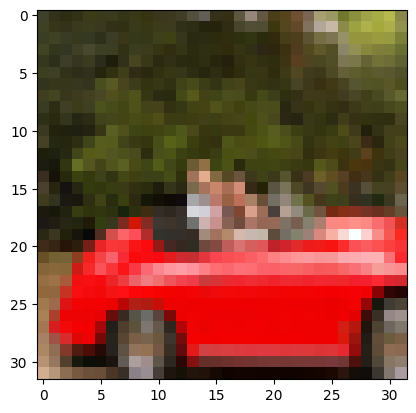

In [5]:
from matplotlib import pyplot as plt

plt.imshow(img)
plt.show()


####  Dataset transforms
That’s all very nice, but we’ll likely need a way to convert the PIL image to a PyTorch
tensor before we can do anything with it. That’s where torchvision.transforms comes
in. We briefly encountered it in chapter 2, where we used transforms to preprocess
images. This module defines a set of composable, function-like objects that can be
passed as an argument to a torchvision dataset, such as datasets.CIFAR10(…), and
that perform transformations on the data after it is loaded but before it is returned by
__getitem__. The list of available objects is as follows:

In [6]:
from torchvision import transforms
dir(transforms)

['AugMix',
 'AutoAugment',
 'AutoAugmentPolicy',
 'CenterCrop',
 'ColorJitter',
 'Compose',
 'ConvertImageDtype',
 'ElasticTransform',
 'FiveCrop',
 'GaussianBlur',
 'Grayscale',
 'InterpolationMode',
 'Lambda',
 'LinearTransformation',
 'Normalize',
 'PILToTensor',
 'Pad',
 'RandAugment',
 'RandomAdjustSharpness',
 'RandomAffine',
 'RandomApply',
 'RandomAutocontrast',
 'RandomChoice',
 'RandomCrop',
 'RandomEqualize',
 'RandomErasing',
 'RandomGrayscale',
 'RandomHorizontalFlip',
 'RandomInvert',
 'RandomOrder',
 'RandomPerspective',
 'RandomPosterize',
 'RandomResizedCrop',
 'RandomRotation',
 'RandomSolarize',
 'RandomVerticalFlip',
 'Resize',
 'TenCrop',
 'ToPILImage',
 'ToTensor',
 'TrivialAugmentWide',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_functional_pil',
 '_functional_tensor',
 '_presets',
 'autoaugment',
 'functional',
 'transforms']

Among those transforms is ToTensor, which turns NumPy arrays and PIL images to
tensors. It also lays out the dimensions of the output tensor as C × H × W (channel,
height, width). (Originally, these images are in H × W × C format, as shown at https://
mng.bz/7QMg.)

 Let’s try out the ToTensor transform. Once instantiated, it can be called like a function with the PIL image as the argument, returning a tensor as output:

In [7]:
from torchvision import transforms
to_tensor = transforms.ToTensor()
img_t = to_tensor(img)
img_t.shape

torch.Size([3, 32, 32])

The image has been turned into a 3 × 32 × 32 tensor and, therefore, a three-channel
(RGB) 32 × 32 image. Nothing has happened to label; it is still an integer.

 For convenience, we can also pass the transform directly as an argument to
datasets.CIFAR10:

In [8]:
tensor_cifar10 = datasets.CIFAR10(data_path, train=True, download=False,
transform=transforms.ToTensor())

At this point, accessing an element of the dataset will return a tensor, rather than a
PIL image:

In [9]:
img_t, _ = tensor_cifar10[99]
type(img_t)

torch.Tensor

As expected, the shape has the channel as the first dimension, while the scalar type is
float32:

In [10]:
img_t.shape, img_t.dtype

(torch.Size([3, 32, 32]), torch.float32)

Whereas the values in the original PIL image ranged from 0 to 255 (8 bits per channel), the ToTensor transform turns the data into a 32-bit floating-point per channel,
scaling the values down from 0.0 to 1.0. Let’s verify that:

In [11]:
img_t.min(), img_t.max()

(tensor(0.), tensor(1.))

And let’s verify that we’re getting the same image out:

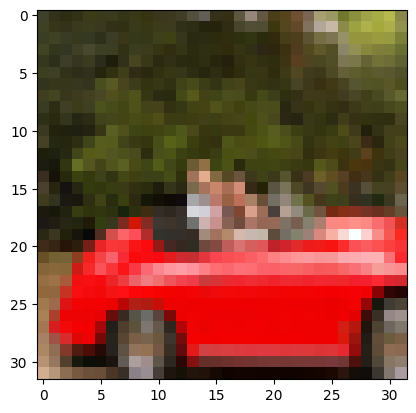

In [12]:
plt.imshow(img_t.permute(1, 2, 0))  # Changes the order of the axes from C × H × W to H × W × C
plt.show()

Note that we have to use
permute to change the order of the axes from C × H × W to H × W × C to match what
Matplotlib expects.


###  Normalizing data
Transforms are really handy because we can chain them using transforms.Compose,
and they can handle normalization and data augmentation transparently, directly
in the data loader. For instance, it’s good practice to normalize the dataset so that
each channel has zero mean and unitary standard deviation. We mentioned this in
chapter 4, but now, after going through chapter 5, we also have an intuition for why:
by choosing activation functions that are linear around 0 plus or minus 1 (or 2),
keeping the data in the same range means it’s more likely that neurons have nonzero
gradients and, hence, will learn sooner. Also, normalizing each channel so that it has
the same distribution will ensure that channel information can be mixed and updated
through gradient descent using the same learning rate. This situation is like that of section 5.4.4, where we rescaled the weight to be of the same magnitude as the bias in our
temperature conversion model.

 To make it so that each channel has zero mean and unitary standard deviation, we
can compute the mean value and the standard deviation of each channel across the
dataset and apply the following transform: v_n[c] = (v[c] - mean[c]) / stdev[c].
This is what transforms.Normalize does. The values of mean and stdev must be computed offline; they are not computed by the transform. Let’s compute them for the
CIFAR-10 training set.

 Since the CIFAR-10 dataset is small, we’ll be able to manipulate it entirely in memory. Let’s stack all the tensors returned by the dataset along an extra dimension:

In [14]:
import torch

imgs = torch.stack([img_t for img_t, _ in tensor_cifar10], dim=3)
imgs.shape

torch.Size([3, 32, 32, 50000])

Now we can easily compute the mean per channel:

In [15]:
mean = imgs.view(3, -1).mean(dim=1)
mean

tensor([0.4914, 0.4822, 0.4465])

Recall that view(3, -1) keeps the three channels and merges all the remaining dimensions into one, figuring out the appropriate size. Here, our 3 × 32 × 32 image is transformed into a 3 × 1,024 vector, and then the mean is taken over the 1,024 elements of
each channel.

 Computing the standard deviation is similar:

In [16]:
std = imgs.view(3, -1).std(dim=1)
std

tensor([0.2470, 0.2435, 0.2616])

With these numbers in our hands, we can initialize the Normalize transform:

In [17]:
transforms.Normalize(mean=mean, std=std)

Normalize(mean=tensor([0.4914, 0.4822, 0.4465]), std=tensor([0.2470, 0.2435, 0.2616]))

and concatenate it after the ToTensor transform:

In [18]:
transformed_cifar10 = datasets.CIFAR10(
    data_path, train=True, download=False,
    transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
]))

At this point, plotting an image drawn from the dataset won’t provide us with a faithful representation of the actual image:

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9802377..2.1267893].


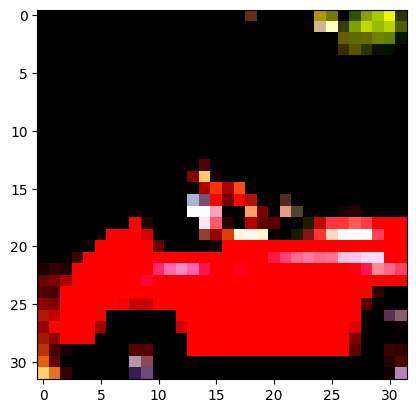

In [19]:
img_t, _ = transformed_cifar10[99]
plt.imshow(img_t.permute(1, 2, 0))
plt.show()

Still, we have a fancy dataset loaded that contains tens of thousands of images! That’s
quite convenient because we were going to need something exactly like it.


### Distinguishing birds from airplanes
Jane, our friend at the bird-watching club, has set up a fleet of cameras in the woods
south of the airport. The cameras are supposed to save a shot when something enters
the frame and upload it to the club’s real-time bird-watching blog. The problem is
that a lot of planes coming and going from the airport end up triggering the camera,
so Jane spends a lot of time deleting pictures of airplanes from the blog. What she
needs is an automated system. Instead of manually deleting, she needs a neural network to throw
away the airplanes right away.


#### Building the dataset
The first step is to get the data in the right shape. We could create a Dataset subclass
that only includes birds and airplanes. However, the dataset is small, and we only need
indexing and len to work on our dataset. It doesn’t actually have to be a subclass of
torch.utils.data.dataset.Dataset!

In [20]:
label_map = {0: 0, 2: 1}
class_names = ['airplane', 'bird']
cifar2 = [(img, label_map[label])
    for img, label in cifar10
    if label in [0, 2]]
cifar2_val = [(img, label_map[label])
    for img, label in cifar10_val
    if label in [0, 2]]

The cifar2 object satisfies the basic requirements for a Dataset—that is, __len__ and
__getitem__ are defined—so we’re going to use that. We should be aware, however,
that this is a clever shortcut, and we might wish to implement a proper Dataset if we
hit limitations with it.

NOTE Here, we built the new dataset manually and also wanted to remap the
classes. In some cases, it may be enough to take a subset of the indices of a given
dataset. We can accomplish this using the torch.utils.data.Subset class. Similarly, we can use ConcatDataset to join datasets (of compatible items) into a
larger one. For iterable datasets, ChainDataset gives a larger, iterable dataset.

We have a dataset! Next, we need a model to feed our data to.


### A fully connected model

We learned how to build a neural network in chapter 5. We know that it’s a tensor of
features in, a tensor of features out. After all, an image is just a set of numbers laid out
in a spatial configuration. OK, we don’t know how to handle the spatial configuration
part just yet, but in theory, if we just take the image pixels and straighten them into a
long 1D vector, we could consider those numbers as input features, right? Figure 7.7
illustrates this concept.

 Let’s try that. How many features per sample? Well, 32 × 32 × 3 is 3,072 input features
per sample. Starting from the model we built in chapter 5, our new model would be an
nn.Linear with 3,072 input features and some number of hidden features, followed by
an activation, and then another nn.Linear that tapers the network down to an appropriate output number of features (2, for this use case, since we have two classes):

In [26]:
import torch.nn as nn

n_out = 2

model = nn.Sequential(
nn.Linear(
3072,   # Input features
512,    # Hidden layer size
),
    nn.Tanh(),
    nn.Linear(
        512,
        n_out,  # Output classes
    )
)

We select 512 hidden features somewhat arbitrarily. A neural network needs at least
one hidden layer (of activations, so two modules) with a nonlinearity in between to be
able to learn arbitrary functions in the way we discussed in section 6.3. Otherwise, it
would just be a linear model. The hidden features represent (learned) relations
between the inputs encoded through the weight matrix. As such, the model might
learn to “compare” vector elements 176 and 208, but it does not a priori focus on
them because it is structurally unaware that these are, indeed, (row 5, pixel 16) and
(row 6, pixel 16), and thus adjacent.

 So, we have a model. Next, we’ll discuss what our model output should be.

###  Output of a classifier
In chapter 6, the network produced the predicted temperature (a number with a
quantitative meaning) as output. We could do something similar here: make our network output a single scalar value (so n_out = 1), cast the labels to floats (0.0 for airplane and 1.0 for bird), and use those as a target for MSELoss (the average of squared
differences in the batch). Doing so, we would cast the problem into a regression problem. However, looking more closely, we are now dealing with something a bit different
in nature.

NOTE Using distance on the “probability” vectors would have already been
much better than using MSELoss with the class numbers, which, recalling our
discussion in chapter 4 of types of values, does not make sense for categories
and does not work at all in practice. Still, MSELoss is not very well suited to
classification problems.

We need to recognize that the output is categorical: it’s either a bird or an airplane
(or something else if we had all 10 of the original classes). As we learned in chapter 4,
when we have to represent a categorical variable, we should switch to a one-hot encoding representation of that variable, such as [1, 0] for airplane or [0, 1] for bird (the
order is arbitrary). This method will still work if we have 10 classes, as in the full
CIFAR-10 dataset; we’ll just have a vector of length 10.

NOTE For the special binary classification case, using two values here is
redundant, as one is always 1 minus the other. Indeed, PyTorch lets us output
only a single probability using the nn.Sigmoid activation at the end of the model
to get a probability and the binary cross-entropy loss function nn.BCELoss. An
nn.BCELossWithLogits is also merging these two steps.

In the ideal case, the network would output torch.tensor([1.0, 0.0]) for an airplane and torch.tensor([0.0, 1.0]) for a bird. Practically speaking, since our classifier will not be perfect, we can expect the network to output something in
between. The key realization in this case is that we can interpret our output as probabilities: the first entry is the probability of “airplane,” and the second is the probability of “bird.”
 Casting the problem in terms of probabilities imposes a few extra constraints on
the outputs of our network:

- Each element of the output must be in the [0.0, 1.0] range. A probability of
an outcome cannot be less than 0 or greater than 1.
- The elements of the output must add up to 1.0. We’re certain that one of the
two outcomes will occur.

It sounds like a tough constraint to enforce in a differentiable way on a vector of numbers. Yet there’s a very smart trick that does exactly that, and it’s differentiable: it’s
called softmax.


###  Representing the output as probabilities

Softmax is a function that takes a vector of values and produces another vector of the
same dimension, where the values satisfy the constraints we just listed to represent
probabilities.

 That is, we take the elements of the vector, compute the elementwise exponential,
and divide each element by the sum of exponentials. In code, it’s something like this:

In [22]:
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum()

Let’s test it on an input vector:

In [23]:
x = torch.tensor([1.0, 2.0, 3.0])

softmax(x)

tensor([0.0900, 0.2447, 0.6652])

As expected, it satisfies the constraints on probability:

In [24]:
softmax(x).sum()

tensor(1.)

Softmax is a monotone function, meaning lower input values will always produce
lower output values, preserving the ranking order. However, it’s not scale invariant—
the ratio between values changes during the transformation. For example, with input
vector [1.0, 2.0, 3.0], the ratio between the first and second elements is 1/2 = 0.5, but
after softmax, it becomes approximately 0.090/0.245 = 0.368. This transformation of
ratios doesn’t hinder learning since the neural network will automatically adjust its
parameters to produce the appropriate logit values needed to generate the desired
probability distribution after softmax is applied.

 The nn module makes softmax available as a module. Since, as usual, input tensors
may have an additional batch zeroth dimension or have dimensions along which they
encode probabilities, and others in which they don’t, nn.Softmax requires us to specify
the dimension along which the softmax function is applied:

In [27]:
softmax = nn.Softmax(dim=1)
x = torch.tensor([[1.0, 2.0, 3.0],
[3.0, 2.0, 1.0]])
softmax(x)

tensor([[0.0900, 0.2447, 0.6652],
        [0.6652, 0.2447, 0.0900]])

In this case, we have two input vectors in two rows (just like when we work with batches),
so we initialize nn.Softmax to operate along dimension 1 (apply softmax to each row).
 Excellent! We can now add a softmax at the end of our model, and our network
will be equipped to produce probabilities:

In [29]:
model = nn.Sequential(
nn.Linear(3072, 512),
nn.Tanh(),
nn.Linear(512, 2),
nn.Softmax(dim=1))

We can try running the model before even training it. Let’s do it, just to see what
comes out. We first build a batch of one image, our bird:

In [34]:
from torchvision import datasets, transforms
cifar10 = datasets.CIFAR10(
    data_path, train=True, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))

In [35]:
cifar10_val = datasets.CIFAR10(
    data_path, train=False, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))

In [36]:
label_map = {0: 0, 2: 1}
class_names = ['airplane', 'bird']

cifar2 = [(img, label_map[label])
          for img, label in cifar10
          if label in [0, 2]]

cifar2_val = [(img, label_map[label])
              for img, label in cifar10_val
              if label in [0, 2]]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8628641..2.029448].


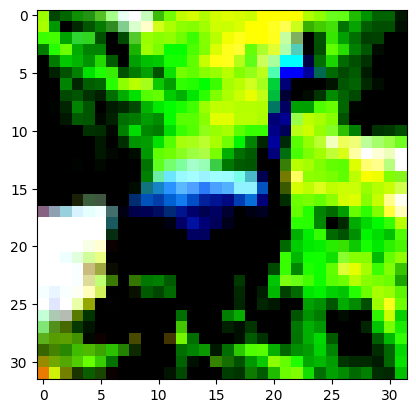

In [37]:
img, _ = cifar2[0]
plt.imshow(img.permute(1, 2, 0))
plt.show()

We can see the picture has some resemblance to a bird after normalization. To call the model, we need to
make the input have the right dimensions. We recall that our model expects 3,072 features in the input and that nn works with data organized into batches along the zeroth
dimension. So, we need to turn our 3 × 32 × 32 image into a 1D tensor and then add
an extra dimension in the zeroth position. We learned how to do this in chapter 3:

In [38]:
img_batch = img.view(-1).unsqueeze(0)
img_batch.shape

torch.Size([1, 3072])

Now we’re ready to invoke our model:

In [39]:
out = model(img_batch)
out

tensor([[0.5144, 0.4856]], grad_fn=<SoftmaxBackward0>)

So, we got probabilities! Well, we know we shouldn’t get too excited: the weights and
biases of our linear layers have not been trained at all. Their elements are initialized
randomly by PyTorch between –1.0 and 1.0. Interestingly, we also see grad_fn for the
output, which is the tip of the backward computation graph (it will be used as soon as
we need to backpropagate).

NOTE While it is, in principle, possible to say that here the model is uncertain (because it assigns 48% and 52% probabilities to the two classes), typical
training results in highly overconfident models. Bayesian neural networks can
provide some remedy, but they are beyond the scope of this book.

In addition, while we know which output probability is supposed to be which (recall
our class_names), our network has no indication of that. Is the first entry “airplane”
and the second “bird,” or the other way around? The network can’t even tell that at
this point. It’s the loss function that associates a meaning with these two numbers,
after backpropagation. If the labels are provided as index 0 for “airplane” and index 1
for “bird,” then that’s the order the outputs will be induced to take.

Thus, after training, we will be able to get the label as an index by computing the
argmax of the output probabilities—that is, the index at which we get the maximum
probability. Conveniently, when supplied with a dimension, torch.max returns the
maximum element along that dimension as well as the index at which that value
occurs. In our case, we need to take the max along the probability vector (not across
batches), therefore, dimension 1:

In [40]:
_, index = torch.max(out, dim=1)

index

tensor([0])

It says the image is a bird. Pure luck. But we have adapted our model output to the
classification task at hand by getting it to output probabilities. We also have now run
our model against an input image and verified that our plumbing works. Time to
get training. As in the previous two chapters, we need a loss to minimize during
training.

We can now modify our model to use nn.LogSoftmax as the output module:

In [41]:
model = nn.Sequential(
nn.Linear(3072, 512),
nn.Tanh(),
nn.Linear(512, 2),
nn.LogSoftmax(dim=1))

In [42]:
loss = nn.NLLLoss()

The loss takes the output of nn.LogSoftmax for a batch as the first argument and a tensor of class indices (zeros and ones, in our case) as the second argument. We can now
test it with our birdie:

In [43]:
img, label = cifar2[0]
out = model(img.view(-1).unsqueeze(0))
loss(out, torch.tensor([label]))

tensor(0.6108, grad_fn=<NllLossBackward0>)

### Training the classifier

In [46]:
import torch
import torch.nn as nn
import torch.optim as optim

model = nn.Sequential(
nn.Linear(3072, 512),
nn.Tanh(),
nn.Linear(512, 2),
nn.LogSoftmax(dim=1))

learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.NLLLoss()
n_epochs = 10

for epoch in range(n_epochs):
    for img, label in cifar2:
        img_tensor = img.view(-1).unsqueeze(0)
        label_tensor = torch.tensor([label])

        out = model(img_tensor)
        loss = loss_fn(out, label_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

Epoch: 0, Loss: 6.346325
Epoch: 1, Loss: 8.119610
Epoch: 2, Loss: 7.786794
Epoch: 3, Loss: 9.212199
Epoch: 4, Loss: 8.554710
Epoch: 5, Loss: 12.364763
Epoch: 6, Loss: 6.606194
Epoch: 7, Loss: 8.705270
Epoch: 8, Loss: 0.640319
Epoch: 9, Loss: 9.294970


You might have noticed that we modified the training loop from before. In chapter 5,
we used a single loop that processed the entire dataset and performed forward propagation, backward propagation, and an optimizer step, repeating this process for N
epochs (where an epoch covers a full pass through the entire training dataset). A
batch is the number of samples processed before the model is updated, so in this case,
each epoch we processed only one batch.

 However, as we have 10,000 images in our dataset, processing all of them in a single
batch would be impractical due to the large batch size. Consequently, we’ve implemented an inner loop where we evaluate one sample at a time and perform backpropagation for that individual sample.

In our training code, we chose minibatches of size 1 by picking one item at a time
from the dataset. The torch.utils.data module has a class that helps with shuffling
and organizing the data in minibatches, DataLoader, which can help us with larger
batch sizes. The job of a data loader is to sample minibatches from a dataset, giving us
the flexibility to choose from different sampling strategies. A very common strategy is
uniform sampling after shuffling the data at each epoch. Figure 7.14 shows the data
loader shuffling the indices it gets from the Dataset.

Let’s see how this is done. At a minimum, the DataLoader constructor takes a Dataset
object as input, along with batch_size and a shuffle Boolean that indicates whether
the data needs to be shuffled at the beginning of each epoch:

In [47]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
shuffle=True)

A DataLoader can be iterated over, so we can use it directly in the inner loop of our
new training code:

In [48]:
model = nn.Sequential(
nn.Linear(3072, 512),
nn.Tanh(),
nn.Linear(512, 2),
nn.LogSoftmax(dim=1))

learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.NLLLoss()
n_epochs = 100

for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        batch_size = imgs.shape[0]
        img_tensor = imgs.view(batch_size, -1)
        label_tensor = torch.tensor(labels)

        out = model(img_tensor)
        loss = loss_fn(out, label_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

C:\Users\brend\AppData\Local\Temp\ipykernel_32252\191220892.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label_tensor = torch.tensor(labels)


Epoch: 0, Loss: 0.314869
Epoch: 1, Loss: 0.388499
Epoch: 2, Loss: 0.298279
Epoch: 3, Loss: 0.325300
Epoch: 4, Loss: 0.425010
Epoch: 5, Loss: 0.273205
Epoch: 6, Loss: 0.424183
Epoch: 7, Loss: 0.528041
Epoch: 8, Loss: 0.464710
Epoch: 9, Loss: 0.309192
Epoch: 10, Loss: 0.203981
Epoch: 11, Loss: 0.220069
Epoch: 12, Loss: 0.488287
Epoch: 13, Loss: 0.387376
Epoch: 14, Loss: 0.390344
Epoch: 15, Loss: 0.354118
Epoch: 16, Loss: 0.268826
Epoch: 17, Loss: 0.413477
Epoch: 18, Loss: 0.343920
Epoch: 19, Loss: 0.273077
Epoch: 20, Loss: 0.415698
Epoch: 21, Loss: 0.557701
Epoch: 22, Loss: 0.226592
Epoch: 23, Loss: 0.162615
Epoch: 24, Loss: 0.215067
Epoch: 25, Loss: 0.109655
Epoch: 26, Loss: 0.494083
Epoch: 27, Loss: 0.171033
Epoch: 28, Loss: 0.313843
Epoch: 29, Loss: 0.243876
Epoch: 30, Loss: 0.147877
Epoch: 31, Loss: 0.227056
Epoch: 32, Loss: 0.209284
Epoch: 33, Loss: 0.135861
Epoch: 34, Loss: 0.156081
Epoch: 35, Loss: 0.179636
Epoch: 36, Loss: 0.315893
Epoch: 37, Loss: 0.295506
Epoch: 38, Loss: 0.063

At each inner iteration, imgs is a tensor of size 64 × 3 × 32 × 32—that is, a minibatch of
64 (32 × 32) RGB images—while labels is a tensor of size 64 containing label indices.

We see that the loss decreases somehow, but we have no idea whether it’s low enough.
Since our goal here is to correctly assign classes to images, preferably on an independent dataset, we can compute the accuracy of our model on the validation set in terms
of the number of correct classifications over the total:

In [49]:
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64,
shuffle=False)
correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        batch_size = imgs.shape[0]
        outputs = model(imgs.view(batch_size, -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())

print("Accuracy: %f", correct / total)

Accuracy: %f 0.8085


Not a great performance, but quite a lot better than random. In our defense, our
model was quite a shallow classifier; it’s a miracle that it worked at all. It did because
our dataset is really simple—a lot of the samples in the two classes likely have systematic differences (such as the color of the background) that help the model tell birds
from airplanes, based on a few pixels.

We can certainly add some bling to our model by including more layers, which will
increase the model’s depth and capacity. One rather arbitrary possibility is

In [ ]:
model = nn.Sequential(
nn.Linear(3072, 1024),
nn.Tanh(),
nn.Linear(1024, 512),
nn.Tanh(),
nn.Linear(512, 128),
nn.Tanh(),
nn.Linear(128, 2),
nn.LogSoftmax(dim=1))

Here, we are trying to taper the number of features more gently toward the output, in
the hope that intermediate layers will do a better job of squeezing information in
increasingly shorter intermediate outputs.

 Combining nn.LogSoftmax and nn.NLLLoss is essentially the same as using nn.CrossEntropyLoss. This might seem a bit puzzling due to PyTorch’s terminology. Here’s
what’s happening:

- nn.NLLLoss computes the cross-entropy but expects log probabilities as inputs.
- nn.CrossEntropyLoss, on the other hand, works with raw scores (often called
logits). Technically, nn.NLLLoss measures the cross-entropy between a distribution that concentrates all its mass on the target and the distribution predicted
from the log probabilities.

It is quite common to drop the last nn.LogSoftmax layer from the network and just use
nn.CrossEntropyLoss as a loss. Let’s try that:

In [ ]:
model = nn.Sequential(
nn.Linear(3072, 1024),
nn.Tanh(),
nn.Linear(1024, 512),
nn.Tanh(),
nn.Linear(512, 128),
nn.Tanh(),
nn.Linear(128, 2))
loss_fn = nn.CrossEntropyLoss()

Note that the numbers will be exactly the same as with nn.LogSoftmax and nn.NLLLoss.
It’s just more convenient to do it all in one pass, with the only gotcha being that the
output of our model will not be interpretable as probabilities (or log probabilities).
We’ll need to explicitly pass the output through a softmax to obtain those.

 Training this larger model and evaluating the accuracy on the validation set gets us
0.813000, a small increase in accuracy, but not much. However, the accuracy on the
training set is perfect (1.000000). What is this result telling us? That we are overfitting
our model in both cases. Our fully connected model is finding a way to discriminate
between birds and airplanes on the training set by memorizing the training set, but performance on the validation set is not all that great, even if we choose a larger model.

 PyTorch offers a quick way to determine how many parameters a model has
through the parameters() method of nn.Module (the same method we use to provide
the parameters to the optimizer). To find out how many elements are in each tensor
instance, we can call the numel method. Summing those gives us our total count.
Depending on our use case, counting parameters might require us to check whether a
parameter has requires_grad set to True, as well. We might want to differentiate the
number of trainable parameters from the overall model size. Let’s take a look at what
we have right now:

In [ ]:
numel_list = [p.numel()
for p in model.parameters()
    if p.requires_grad == True]
sum(numel_list), numel_list

Wow, 3.7 million parameters! That’s quite substantial to handle such a small input
size, isn’t it?


### The limits of going fully connected

Let’s reason about what using a linear module on a 1D view of our image entails; figure 7.15 visualizes what is going on. It’s like taking every single input value—that is,
every single component in our RGB image—and computing a linear combination of
it with all the other values for every output feature. On one hand, we are allowing for
the combination of any pixel with every other pixel in the image being potentially relevant for our task. On the other hand, we aren’t utilizing the relative position of neighboring or far-away pixels, since we are treating the image as one big vector of numbers.

Being fully connected doesn't scale or generalize well.

Next we will look at introducing convolutional layers to reduce the connectivity, reduce parameter size, capture local structure, and improve generalization.